In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
df = yf.download("GOOG", start="2015-01-01", end="2024-01-01")

df.head()

/tmp/ipykernel_5832/1801698310.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GOOG", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2015-01-02,25.955559,26.275053,25.920445,26.163278,28951268
2015-01-05,25.414499,25.931820,25.374440,25.878901,41196796
2015-01-06,24.825464,25.528497,24.780460,25.470385,57998800
2015-01-07,24.782934,25.086798,24.711221,25.074730,41301082
2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641


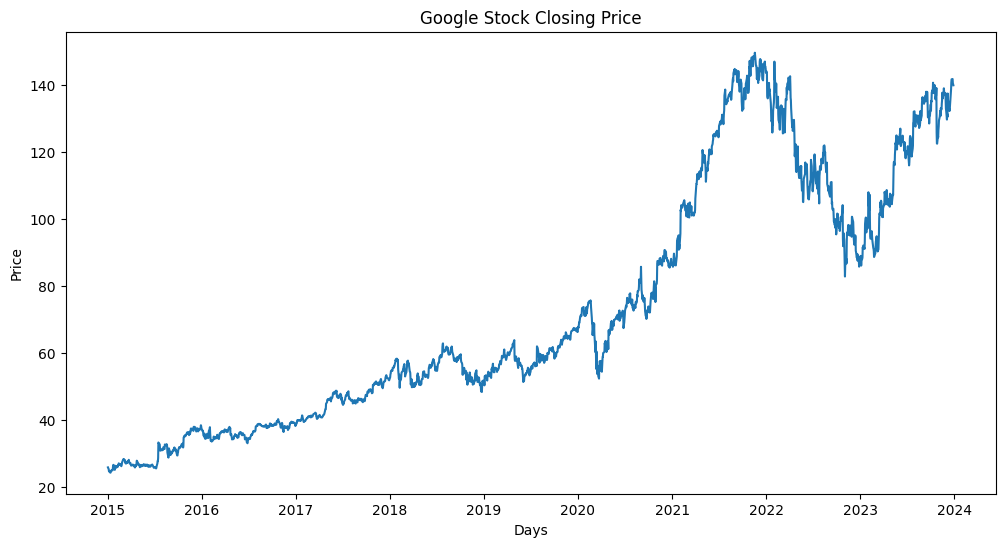

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Google Stock Closing Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

In [5]:
data = df['Close'].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [6]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2204, 60, 1)
(2204, 1)


In [7]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

In [8]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [9]:
batch_size = 32

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [10]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(SimpleRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, _ = self.rnn(x, h0)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, _ = self.lstm(x, (h0, c0))

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [12]:
def train_model(model, train_loader, epochs=20, lr=0.001):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):

        model.train()

        epoch_loss = 0

        for inputs, targets in train_loader:

            outputs = model(inputs)

            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)

        losses.append(avg_loss)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

    return losses

In [13]:
rnn_model = SimpleRNN()

rnn_losses = train_model(rnn_model, train_loader)

Epoch [1/20], Loss: 0.025449
Epoch [2/20], Loss: 0.000282
Epoch [3/20], Loss: 0.000238
Epoch [4/20], Loss: 0.000231
Epoch [5/20], Loss: 0.000212
Epoch [6/20], Loss: 0.000258
Epoch [7/20], Loss: 0.000218
Epoch [8/20], Loss: 0.000210
Epoch [9/20], Loss: 0.000212
Epoch [10/20], Loss: 0.000228
Epoch [11/20], Loss: 0.000229
Epoch [12/20], Loss: 0.000183
Epoch [13/20], Loss: 0.000179
Epoch [14/20], Loss: 0.000198
Epoch [15/20], Loss: 0.000194
Epoch [16/20], Loss: 0.000231
Epoch [17/20], Loss: 0.000189
Epoch [18/20], Loss: 0.000175
Epoch [19/20], Loss: 0.000197
Epoch [20/20], Loss: 0.000168


In [14]:
lstm_model = LSTMModel()

lstm_losses = train_model(lstm_model, train_loader)

Epoch [1/20], Loss: 0.041136
Epoch [2/20], Loss: 0.001631
Epoch [3/20], Loss: 0.000325
Epoch [4/20], Loss: 0.000332
Epoch [5/20], Loss: 0.000314
Epoch [6/20], Loss: 0.000302
Epoch [7/20], Loss: 0.000306
Epoch [8/20], Loss: 0.000327
Epoch [9/20], Loss: 0.000320
Epoch [10/20], Loss: 0.000300
Epoch [11/20], Loss: 0.000312
Epoch [12/20], Loss: 0.000299
Epoch [13/20], Loss: 0.000302
Epoch [14/20], Loss: 0.000296
Epoch [15/20], Loss: 0.000288
Epoch [16/20], Loss: 0.000367
Epoch [17/20], Loss: 0.000273
Epoch [18/20], Loss: 0.000307
Epoch [19/20], Loss: 0.000264
Epoch [20/20], Loss: 0.000254


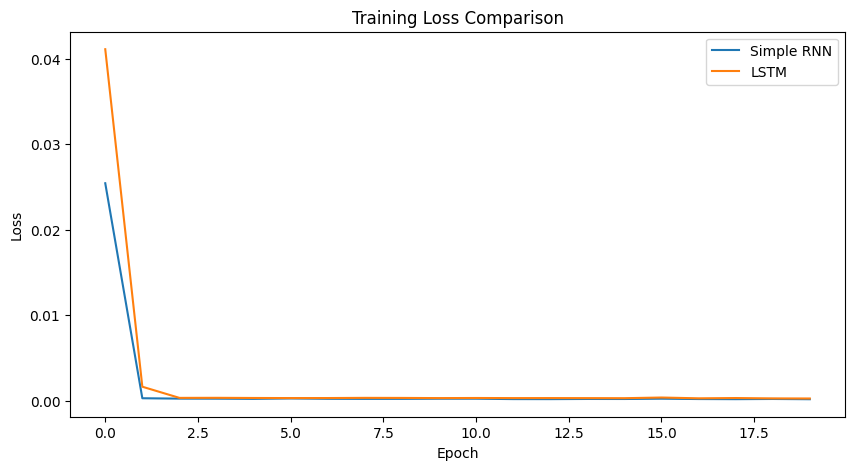

In [15]:
plt.figure(figsize=(10,5))

plt.plot(rnn_losses, label="Simple RNN")
plt.plot(lstm_losses, label="LSTM")

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [16]:
def predict(model, X_test):

    model.eval()

    with torch.no_grad():
        predictions = model(X_test)

    return predictions.numpy()

In [18]:
rnn_predictions = predict(rnn_model, X_test)
lstm_predictions = predict(lstm_model, X_test)

In [19]:
rnn_predictions = scaler.inverse_transform(rnn_predictions)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

y_actual = scaler.inverse_transform(y_test.numpy())

In [20]:
rnn_rmse = np.sqrt(mean_squared_error(y_actual, rnn_predictions))
lstm_rmse = np.sqrt(mean_squared_error(y_actual, lstm_predictions))

print("Simple RNN RMSE:", rnn_rmse)
print("LSTM RMSE:", lstm_rmse)

Simple RNN RMSE: 3.4897851382684433
LSTM RMSE: 4.2675137652469575


# Predictions vs ACtual Values

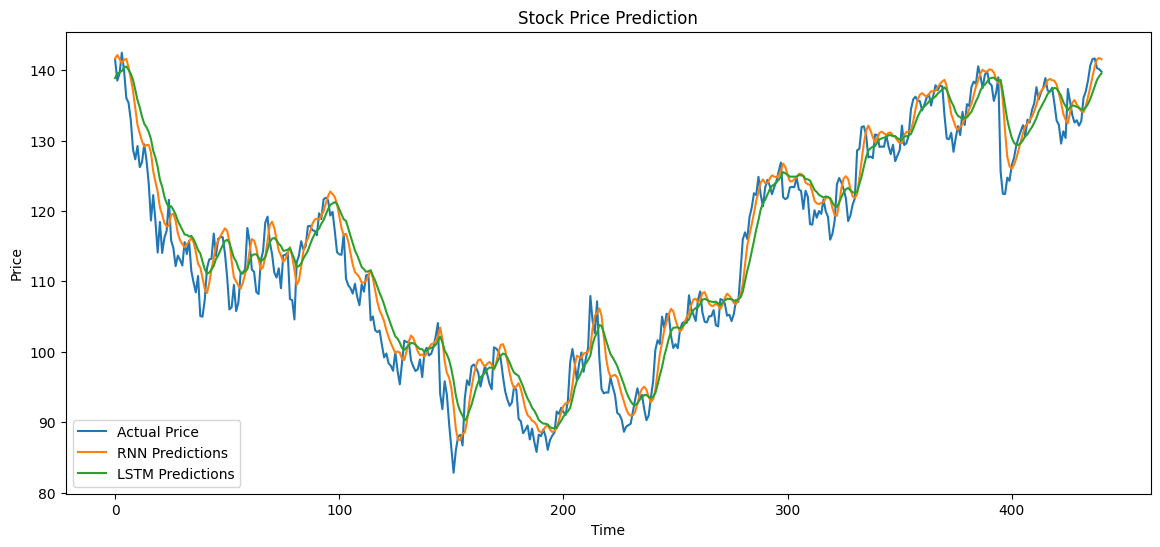

In [21]:
plt.figure(figsize=(14,6))

plt.plot(y_actual, label="Actual Price")
plt.plot(rnn_predictions, label="RNN Predictions")
plt.plot(lstm_predictions, label="LSTM Predictions")

plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.show()

In [22]:
last_sequence = scaled_data[-sequence_length:]

future_input = torch.tensor(
    last_sequence.reshape(1, sequence_length, 1),
    dtype=torch.float32
)

lstm_model.eval()

with torch.no_grad():
    future_prediction = lstm_model(future_input)

future_prediction = scaler.inverse_transform(
    future_prediction.numpy()
)

print("Predicted Future Price:", future_prediction[0][0])

Predicted Future Price: 139.79991


# **Discussion of Results**

While training we can see that a SImple RNN converges faster than an LSTM, thought there is not a marked difference between their training losses.

In terms of RMSE, RNN has a lower one of 3.489 while LSTM has 4.267.

In the graph of predictions vs Actual Price, one can see that RNN follows the curve better than LSTM. Though both are close to the Actual Curve. LSTM is much more smoother and does not have the spikes that are present in the actual data.

